# Notebook 12 - Final Analysis and Project Summary

This notebook is the capstone report for the Speech Emotion Recognition project. The earlier notebooks show the detailed build-up: data audit, feature extraction, MiniLearn implementations, model families, validation, clustering, dimensionality reduction, and neural networks. This notebook pulls those pieces into one concise final analysis.

The goal here is not to rerun every grid search. It reruns the fixed final models on the same stratified split, reports the required metrics, and explains what the results mean for the project.

In [1]:
from pathlib import Path
import sys
import time
import warnings

ROOT = Path.cwd()
for candidate in [ROOT, ROOT.parent, ROOT / "serProject", ROOT.parent / "serProject"]:
    if (candidate / "features" / "features.csv").exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans as SkKMeans
from sklearn.ensemble import (
    AdaBoostClassifier as SkAdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier as SkRandomForestClassifier,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression as SkLogisticRegression
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    auc,
    classification_report,
    confusion_matrix as sk_confusion_matrix,
    f1_score,
    normalized_mutual_info_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    silhouette_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import GaussianNB as SkGaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier as SkMLPClassifier
from sklearn.preprocessing import label_binarize
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier as SkDecisionTreeClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    XGBClassifier = None
    HAS_XGBOOST = False

from minilearn.classifiers import (
    AdaBoostClassifier,
    DecisionTreeClassifier,
    GaussianNaiveBayes,
    KNN,
    LinearSVM,
    LogisticRegression,
    MLPClassifier,
    RandomForestClassifier,
)
from minilearn.clustering import KMeans
from minilearn.metrics import confusion_matrix, plot_confusion_matrix
from minilearn.preprocessing import PCA, StandardScaler, train_test_split

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 432
FEATURE_PATH = ROOT / "features" / "features.csv"

## 1. Dataset and target

The dataset is RAVDESS audio-only speech/song clips represented as one row per file. The supervised target is `emotion_id`, which maps to eight emotion labels. Metadata columns are kept for auditing and plots, but they are not model inputs.

In [2]:
META_COLS = {
    "filename",
    "emotion",
    "emotion_id",
    "actor",
    "gender",
    "vocalchannel",
    "intensity",
    "statement",
    "repetition",
    "duration",
}

df = pd.read_csv(FEATURE_PATH)
feature_cols = [c for c in df.columns if c not in META_COLS]
X = df[feature_cols].to_numpy(dtype=float)
y = df["emotion_id"].to_numpy()

emotion_names = (
    df[["emotion_id", "emotion"]]
    .drop_duplicates()
    .sort_values("emotion_id")
    .set_index("emotion_id")["emotion"]
    .to_dict()
)
labels = sorted(emotion_names)
target_names = [emotion_names[i] for i in labels]

summary = pd.DataFrame([
    {"item": "rows", "value": len(df)},
    {"item": "metadata_columns", "value": len(META_COLS)},
    {"item": "feature_columns", "value": len(feature_cols)},
    {"item": "emotion_classes", "value": len(labels)},
])

class_counts = (
    df["emotion"]
    .value_counts()
    .rename_axis("emotion")
    .reset_index(name="count")
)

display(summary)
display(class_counts)

,item,value
0,rows,2452
1,metadata_columns,10
2,feature_columns,407
3,emotion_classes,8


,emotion,count
0,calm,376
1,happy,376
2,sad,376
3,angry,376
4,fearful,376
5,disgust,192
6,surprised,192
7,neutral,188


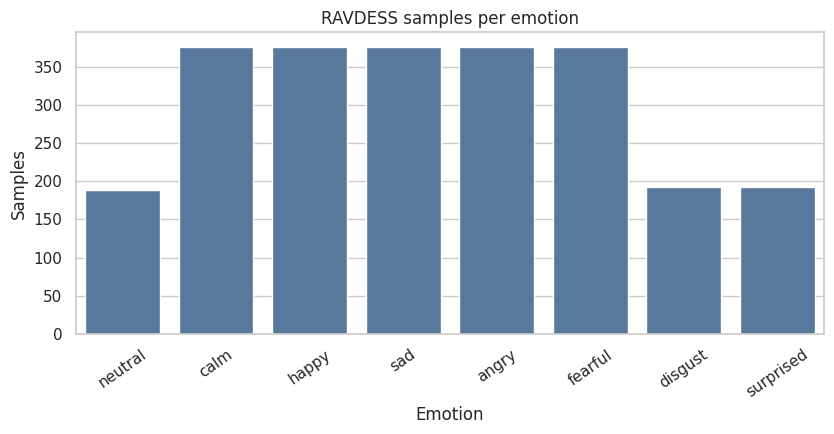

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
sns.countplot(data=df, x="emotion", order=target_names, color="#4C78A8", ax=ax)
ax.set_title("RAVDESS samples per emotion")
ax.set_xlabel("Emotion")
ax.set_ylabel("Samples")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

The class distribution is close enough for stratified evaluation, but not perfectly even. That is why the project uses macro F1 alongside accuracy: each emotion should count, including the smaller neutral, disgust, and surprised groups.

## 2. Feature engineering and scaling

Notebook 2 extracted fixed-length summary features from variable-length audio clips. The final feature table has 407 numeric columns built from MFCC, delta MFCC, chroma, mel-spectrogram, spectral, zero-crossing, RMS, and related summary statistics.

The important evaluation rule is that scaling is fit only on the training split. KNN, SVM, logistic regression, PCA, clustering, and MLP models are scale-sensitive; fitting a scaler on the full dataset would leak test-set information.

In [4]:
def feature_family(col):
    lower = col.lower()
    for key in ["mfcc_delta2", "mfcc_delta", "mfcc", "mel", "chroma", "contrast", "tonnetz", "centroid", "bandwidth", "rolloff", "zcr", "rms"]:
        if lower.startswith(key) or key in lower:
            return key
    return "other"

feature_summary = (
    pd.Series([feature_family(c) for c in feature_cols])
    .value_counts()
    .rename_axis("feature_family")
    .reset_index(name="columns")
)
feature_summary

,feature_family,columns
0,mel,256
1,mfcc,117
2,chroma,24
3,zcr,2
4,rms,2
5,centroid,2
6,bandwidth,2
7,rolloff,2


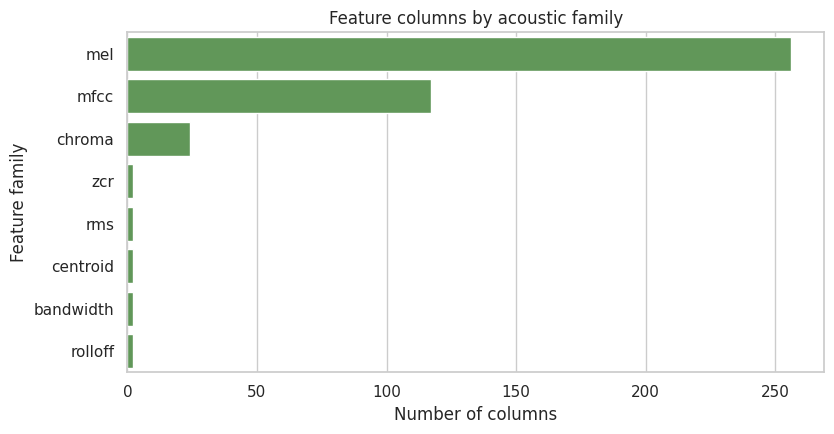

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
sns.barplot(data=feature_summary, y="feature_family", x="columns", color="#59A14F", ax=ax)
ax.set_title("Feature columns by acoustic family")
ax.set_xlabel("Number of columns")
ax.set_ylabel("Feature family")
plt.tight_layout()
plt.show()

## 3. Final train/test split

All final supervised results below use the same split and target so the comparison is not stitched together from incompatible runs. Models that need scaling receive `X_train_s` and `X_test_s`; tree models and Naive Bayes use the raw extracted feature scale.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"train rows: {len(X_train)}")
print(f"test rows: {len(X_test)}")
print(f"scaled training mean range: {X_train_s.mean(axis=0).min():.3g} to {X_train_s.mean(axis=0).max():.3g}")
print(f"scaled training std range: {X_train_s.std(axis=0).min():.3g} to {X_train_s.std(axis=0).max():.3g}")

train rows: 1963
test rows: 489
scaled training mean range: -2.14e-14 to 2.27e-14
scaled training std range: 1 to 1


## 4. MiniLearn implementation coverage

MiniLearn is the from-scratch part of the project. It is not meant to outperform optimized libraries; it demonstrates that the major algorithms and metrics can be implemented and explained directly.

In [7]:
minilearn_coverage = pd.DataFrame([
    {"area": "preprocessing", "implemented": "train_test_split, StandardScaler, PCA"},
    {"area": "metrics", "implemented": "accuracy, precision, recall, F1, classification report, confusion matrix, stratified folds"},
    {"area": "classifiers", "implemented": "Logistic Regression, Gaussian NB, KNN, Linear SVM, Decision Tree, Random Forest, AdaBoost, MLP"},
    {"area": "clustering", "implemented": "KMeans"},
])
minilearn_coverage

,area,implemented
0,preprocessing,"train_test_split, StandardScaler, PCA"
1,metrics,"accuracy, precision, recall, F1, classificatio..."
2,classifiers,"Logistic Regression, Gaussian NB, KNN, Linear ..."
3,clustering,KMeans


## 5. Supervised model comparison

This table is the main supervised comparison. It includes classical models, ensemble/boosting models, and neural networks. Hyperparameters are fixed to the validated or previously selected settings so this notebook stays readable and rerunnable.

In [8]:
def make_model_specs():
    specs = [
        {
            "name": "MiniLearn Logistic Regression",
            "family": "MiniLearn linear",
            "model": LogisticRegression(learning_rate=0.08, max_iter=700, reg_strength=0.001, tol=1e-7),
            "scaled": True,
            "kind": "normal",
            "params": "lr=0.08, reg=0.001, max_iter=700",
        },
        {
            "name": "MiniLearn Gaussian NB",
            "family": "MiniLearn baseline",
            "model": GaussianNaiveBayes(),
            "scaled": False,
            "kind": "normal",
            "params": "default",
        },
        {
            "name": "MiniLearn KNN",
            "family": "MiniLearn distance",
            "model": KNN(k=7, weights="distance"),
            "scaled": True,
            "kind": "normal",
            "params": "k=7, distance weights",
        },
        {
            "name": "MiniLearn Linear SVM",
            "family": "MiniLearn linear",
            "model": LinearSVM(learning_rate=0.001, max_iter=800, reg_strength=0.01, random_state=RANDOM_STATE),
            "scaled": True,
            "kind": "normal",
            "params": "lr=0.001, reg=0.01, max_iter=800",
        },
        {
            "name": "MiniLearn Decision Tree",
            "family": "MiniLearn tree",
            "model": DecisionTreeClassifier(max_depth=7, min_samples_leaf=2),
            "scaled": False,
            "kind": "normal",
            "params": "max_depth=7, min_leaf=2",
        },
        {
            "name": "MiniLearn Random Forest",
            "family": "MiniLearn ensemble",
            "model": RandomForestClassifier(n_estimators=16, max_depth=7, min_samples_leaf=2, max_features="sqrt", max_samples=0.85, random_state=RANDOM_STATE),
            "scaled": False,
            "kind": "normal",
            "params": "16 trees, sqrt features, max_depth=7",
        },
        {
            "name": "MiniLearn AdaBoost",
            "family": "MiniLearn ensemble",
            "model": AdaBoostClassifier(n_estimators=20, learning_rate=0.65, max_depth=1, min_samples_leaf=2, random_state=RANDOM_STATE),
            "scaled": False,
            "kind": "normal",
            "params": "20 stumps, lr=0.65",
        },
        {
            "name": "MiniLearn MLP",
            "family": "MiniLearn neural net",
            "model": MLPClassifier(hidden_units=64, learning_rate=0.008, max_iter=160, batch_size=64, reg_strength=0.003, validation_split=0.2, random_state=RANDOM_STATE),
            "scaled": True,
            "kind": "normal",
            "params": "64 hidden, ReLU, softmax, L2=0.003",
        },
        {
            "name": "sklearn Logistic Regression",
            "family": "sklearn linear",
            "model": SkLogisticRegression(max_iter=1500, C=0.5),
            "scaled": True,
            "kind": "normal",
            "params": "C=0.5, max_iter=1500",
        },
        {
            "name": "sklearn Gaussian NB",
            "family": "sklearn baseline",
            "model": SkGaussianNB(),
            "scaled": False,
            "kind": "normal",
            "params": "default",
        },
        {
            "name": "sklearn KNN",
            "family": "sklearn distance",
            "model": KNeighborsClassifier(n_neighbors=7, weights="distance"),
            "scaled": True,
            "kind": "normal",
            "params": "k=7, distance weights",
        },
        {
            "name": "sklearn Linear SVM",
            "family": "sklearn linear",
            "model": LinearSVC(C=0.25, max_iter=5000, random_state=RANDOM_STATE),
            "scaled": True,
            "kind": "normal",
            "params": "C=0.25",
        },
        {
            "name": "sklearn RBF SVM",
            "family": "sklearn kernel",
            "model": SVC(kernel="rbf", C=10, gamma="scale", decision_function_shape="ovr", random_state=RANDOM_STATE),
            "scaled": True,
            "kind": "normal",
            "params": "C=10, gamma=scale",
        },
        {
            "name": "sklearn Poly SVM",
            "family": "sklearn kernel",
            "model": SVC(kernel="poly", degree=3, C=1.0, gamma="scale", decision_function_shape="ovr", random_state=RANDOM_STATE),
            "scaled": True,
            "kind": "normal",
            "params": "degree=3, C=1, gamma=scale",
        },
        {
            "name": "sklearn Decision Tree",
            "family": "sklearn tree",
            "model": SkDecisionTreeClassifier(max_depth=7, min_samples_leaf=2, random_state=RANDOM_STATE),
            "scaled": False,
            "kind": "normal",
            "params": "max_depth=7, min_leaf=2",
        },
        {
            "name": "sklearn Random Forest",
            "family": "sklearn ensemble",
            "model": SkRandomForestClassifier(n_estimators=180, min_samples_leaf=2, max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1),
            "scaled": False,
            "kind": "normal",
            "params": "180 trees, sqrt features, min_leaf=2",
        },
        {
            "name": "sklearn AdaBoost",
            "family": "sklearn ensemble",
            "model": SkAdaBoostClassifier(estimator=SkDecisionTreeClassifier(max_depth=1, min_samples_leaf=2, random_state=RANDOM_STATE), n_estimators=80, learning_rate=0.5, random_state=RANDOM_STATE),
            "scaled": False,
            "kind": "normal",
            "params": "80 stumps, lr=0.5",
        },
        {
            "name": "sklearn Gradient Boosting",
            "family": "sklearn ensemble",
            "model": GradientBoostingClassifier(n_estimators=25, learning_rate=0.08, max_depth=2, subsample=0.85, random_state=RANDOM_STATE),
            "scaled": False,
            "kind": "normal",
            "params": "25 trees, lr=0.08, max_depth=2",
        },
        {
            "name": "sklearn MLP",
            "family": "sklearn neural net",
            "model": SkMLPClassifier(hidden_layer_sizes=(64,), activation="relu", solver="adam", alpha=0.003, batch_size=64, learning_rate_init=0.001, max_iter=300, early_stopping=True, validation_fraction=0.2, n_iter_no_change=20, random_state=RANDOM_STATE),
            "scaled": True,
            "kind": "normal",
            "params": "64 hidden, Adam, early stopping, alpha=0.003",
        },
    ]
    if HAS_XGBOOST:
        specs.append({
            "name": "XGBoost",
            "family": "boosted trees",
            "model": XGBClassifier(n_estimators=90, max_depth=3, learning_rate=0.07, subsample=0.85, colsample_bytree=0.75, objective="multi:softprob", eval_metric="mlogloss", tree_method="hist", random_state=RANDOM_STATE, n_jobs=2),
            "scaled": False,
            "kind": "xgboost",
            "params": "90 trees, depth=3, lr=0.07",
        })
    return specs

model_specs = make_model_specs()
pd.DataFrame([{k: spec[k] for k in ["name", "family", "scaled", "params"]} for spec in model_specs])

,name,family,scaled,params
0,MiniLearn Logistic Regression,MiniLearn linear,True,"lr=0.08, reg=0.001, max_iter=700"
1,MiniLearn Gaussian NB,MiniLearn baseline,False,default
2,MiniLearn KNN,MiniLearn distance,True,"k=7, distance weights"
3,MiniLearn Linear SVM,MiniLearn linear,True,"lr=0.001, reg=0.01, max_iter=800"
4,MiniLearn Decision Tree,MiniLearn tree,False,"max_depth=7, min_leaf=2"
5,MiniLearn Random Forest,MiniLearn ensemble,False,"16 trees, sqrt features, max_depth=7"
6,MiniLearn AdaBoost,MiniLearn ensemble,False,"20 stumps, lr=0.65"
7,MiniLearn MLP,MiniLearn neural net,True,"64 hidden, ReLU, softmax, L2=0.003"
8,sklearn Logistic Regression,sklearn linear,True,"C=0.5, max_iter=1500"
9,sklearn Gaussian NB,sklearn baseline,False,default


In [9]:
def evaluate_model(spec):
    model = spec["model"]
    Xtr = X_train_s if spec["scaled"] else X_train
    Xte = X_test_s if spec["scaled"] else X_test
    ytr = y_train - 1 if spec["kind"] == "xgboost" else y_train

    start = time.perf_counter()
    model.fit(Xtr, ytr)
    fit_seconds = time.perf_counter() - start

    start = time.perf_counter()
    pred = model.predict(Xte)
    predict_seconds = time.perf_counter() - start
    if spec["kind"] == "xgboost":
        pred = pred + 1

    row = {
        "model": spec["name"],
        "family": spec["family"],
        "scaled": spec["scaled"],
        "best_hyperparameters": spec["params"],
        "accuracy": accuracy_score(y_test, pred),
        "macro_precision": precision_score(y_test, pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_test, pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_test, pred, average="macro", zero_division=0),
        "weighted_precision": precision_score(y_test, pred, average="weighted", zero_division=0),
        "weighted_recall": recall_score(y_test, pred, average="weighted", zero_division=0),
        "weighted_f1": f1_score(y_test, pred, average="weighted", zero_division=0),
        "fit_seconds": fit_seconds,
        "predict_seconds": predict_seconds,
    }
    return model, pred, row

fitted = {}
predictions = {}
rows = []

for spec in model_specs:
    print(f"fitting {spec['name']}...")
    model, pred, row = evaluate_model(spec)
    fitted[spec["name"]] = {**spec, "model": model}
    predictions[spec["name"]] = pred
    rows.append(row)

results = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
metric_cols = [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1",
    "fit_seconds",
    "predict_seconds",
]
results_display = results.copy()
results_display[metric_cols] = results_display[metric_cols].round(4)
results_display

fitting MiniLearn Logistic Regression...


fitting MiniLearn Gaussian NB...
fitting MiniLearn KNN...


fitting MiniLearn Linear SVM...


fitting MiniLearn Decision Tree...


fitting MiniLearn Random Forest...


...

fitting sklearn AdaBoost...


fitting sklearn Gradient Boosting...


fitting sklearn MLP...


fitting XGBoost...


,model,family,scaled,best_hyperparameters,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,fit_seconds,predict_seconds
0,sklearn RBF SVM,sklearn kernel,True,"C=10, gamma=scale",0.8037,0.8020,0.7897,0.7928,0.8052,0.8037,0.8024,0.6109,0.2605
1,sklearn MLP,sklearn neural net,True,"64 hidden, Adam, early stopping, alpha=0.003",0.7137,0.7098,0.7050,0.7044,0.7155,0.7137,0.7119,1.4372,0.0034
2,sklearn Linear SVM,sklearn linear,True,C=0.25,0.7198,0.7020,0.7068,0.7037,0.7214,0.7198,0.7199,2.1045,0.0086
3,MiniLearn MLP,MiniLearn neural net,True,"64 hidden, ReLU, softmax, L2=0.003",0.7137,0.7085,0.7018,0.7026,0.7156,0.7137,0.7122,3.9682,0.0093
4,sklearn Logistic Regression,sklearn linear,True,"C=0.5, max_iter=1500",0.6953,0.6836,0.6835,0.6824,0.6974,0.6953,0.6952,15.4663,0.0010
5,MiniLearn Logistic Regression,MiniLearn linear,True,"lr=0.08, reg=0.001, max_iter=700",0.6892,0.6803,0.6850,0.6816,0.6886,0.6892,0.6877,2.1154,0.0024
6,XGBoost,boosted trees,False,"90 trees, depth=3, lr=0.07",0.6667,0.6668,0.6602,0.6588,0.6705,0.6667,0.6647,8.4624,0.0034
7,sklearn Random Forest,sklearn ensemble,False,"180 trees, sqrt features, min_leaf=2",0.6687,0.6645,0.6440,0.6479,0.6738,0.6687,0.6658,1.4220,0.1965
8,MiniLearn KNN,MiniLearn distance,True,"k=7, distance weights",0.6524,0.6344,0.6339,0.6302,0.6591,0.6524,0.6514,0.0000,2.6076
9,sklearn KNN,sklearn distance,True,"k=7, distance weights",0.6524,0.6344,0.6339,0.6302,0.6591,0.6524,0.6514,0.0020,0.0753


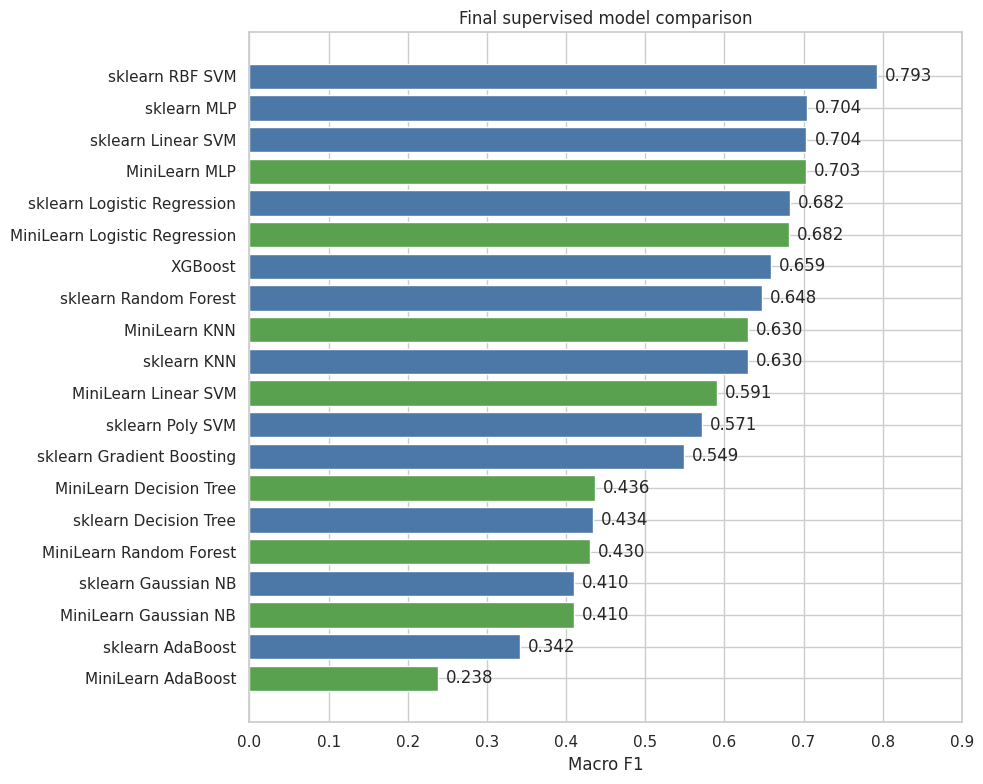

In [10]:
plot_df = results_display.sort_values("macro_f1", ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
colors = np.where(plot_df["model"].str.startswith("MiniLearn"), "#59A14F", "#4C78A8")
ax.barh(plot_df["model"], plot_df["macro_f1"], color=colors)
ax.set_xlabel("Macro F1")
ax.set_title("Final supervised model comparison")
ax.set_xlim(0, max(0.9, plot_df["macro_f1"].max() + 0.08))
for i, value in enumerate(plot_df["macro_f1"]):
    ax.text(value + 0.01, i, f"{value:.3f}", va="center")
plt.tight_layout()
plt.show()

The validated RBF SVM is the strongest overall model. That matches the earlier tuning notebook: nonlinear boundaries help on this tabular audio-feature space. MiniLearn MLP is the strongest MiniLearn row in this final rerun, while MiniLearn Logistic Regression remains the strongest classical MiniLearn baseline. The shallow neural net learns useful signal, but it still does not beat the kernel SVM.

## 6. Validation-backed finalists

Notebook 8 performed the actual hyperparameter selection using stratified folds inside the training split. This notebook does not rerun the full grid. The table below records the validated finalists and the held-out test scores from the fixed final settings.

In [11]:
validated_models = [
    "sklearn RBF SVM",
    "MiniLearn Logistic Regression",
    "sklearn MLP",
    "MiniLearn MLP",
    "XGBoost" if HAS_XGBOOST else None,
    "sklearn Random Forest",
    "MiniLearn KNN",
]
validated_models = [m for m in validated_models if m in set(results["model"])]
validated_finalists = results_display[results_display["model"].isin(validated_models)].copy()
validated_finalists = validated_finalists.sort_values("macro_f1", ascending=False).reset_index(drop=True)
validated_finalists[["model", "family", "best_hyperparameters", "accuracy", "macro_f1", "weighted_f1", "fit_seconds"]]

,model,family,best_hyperparameters,accuracy,macro_f1,weighted_f1,fit_seconds
0,sklearn RBF SVM,sklearn kernel,"C=10, gamma=scale",0.8037,0.7928,0.8024,0.6109
1,sklearn MLP,sklearn neural net,"64 hidden, Adam, early stopping, alpha=0.003",0.7137,0.7044,0.7119,1.4372
2,MiniLearn MLP,MiniLearn neural net,"64 hidden, ReLU, softmax, L2=0.003",0.7137,0.7026,0.7122,3.9682
3,MiniLearn Logistic Regression,MiniLearn linear,"lr=0.08, reg=0.001, max_iter=700",0.6892,0.6816,0.6877,2.1154
4,XGBoost,boosted trees,"90 trees, depth=3, lr=0.07",0.6667,0.6588,0.6647,8.4624
5,sklearn Random Forest,sklearn ensemble,"180 trees, sqrt features, min_leaf=2",0.6687,0.6479,0.6658,1.4220
6,MiniLearn KNN,MiniLearn distance,"k=7, distance weights",0.6524,0.6302,0.6514,0.0000


In [12]:
cv_model = SVC(kernel="rbf", C=10, gamma="scale", decision_function_shape="ovr", random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(cv_model, X_train_s, y_train, cv=cv, scoring="f1_macro")
pd.DataFrame({
    "model": ["sklearn RBF SVM"],
    "cv_folds": [3],
    "mean_cv_macro_f1": [cv_scores.mean()],
    "std_cv_macro_f1": [cv_scores.std()],
    "heldout_macro_f1": [results.loc[results["model"].eq("sklearn RBF SVM"), "macro_f1"].iloc[0]],
}).round(4)

,model,cv_folds,mean_cv_macro_f1,std_cv_macro_f1,heldout_macro_f1
0,sklearn RBF SVM,3,0.7759,0.0073,0.7928


The cross-validation check is intentionally small here because the full validation notebook already did the model selection. Its purpose in the final notebook is to show that the held-out result is not an isolated lucky split.

## 7. Best-model reports and confusion matrices

Overall accuracy is not enough for SER. The confusion matrices and per-class reports show which emotions carry the remaining mistakes.

In [13]:
best_overall = results.iloc[0]["model"]
best_minilearn = results[results["model"].str.startswith("MiniLearn")].iloc[0]["model"]
print("Best overall:", best_overall)
print("Best MiniLearn:", best_minilearn)

for name in [best_overall, best_minilearn]:
    print("\n" + "=" * 72)
    print(name)
    print(classification_report(y_test, predictions[name], labels=labels, target_names=target_names, zero_division=0))

Best overall: sklearn RBF SVM
Best MiniLearn: MiniLearn MLP

sklearn RBF SVM
              precision    recall  f1-score   support

     neutral       0.75      0.79      0.77        38
        calm       0.89      0.96      0.92        75
       happy       0.79      0.81      0.80        75
         sad       0.74      0.73      0.74        75
       angry       0.86      0.85      0.86        75
     fearful       0.76      0.77      0.77        75
     disgust       0.72      0.76      0.74        38
   surprised       0.89      0.63      0.74        38

    accuracy                           0.80       489
   macro avg       0.80      0.79      0.79       489
weighted avg       0.81      0.80      0.80       489


MiniLearn MLP
              precision    recall  f1-score   support

     neutral       0.81      0.66      0.72        38
        calm       0.77      0.95      0.85        75
       happy       0.76      0.72      0.74        75
         sad       0.60      0.59      0

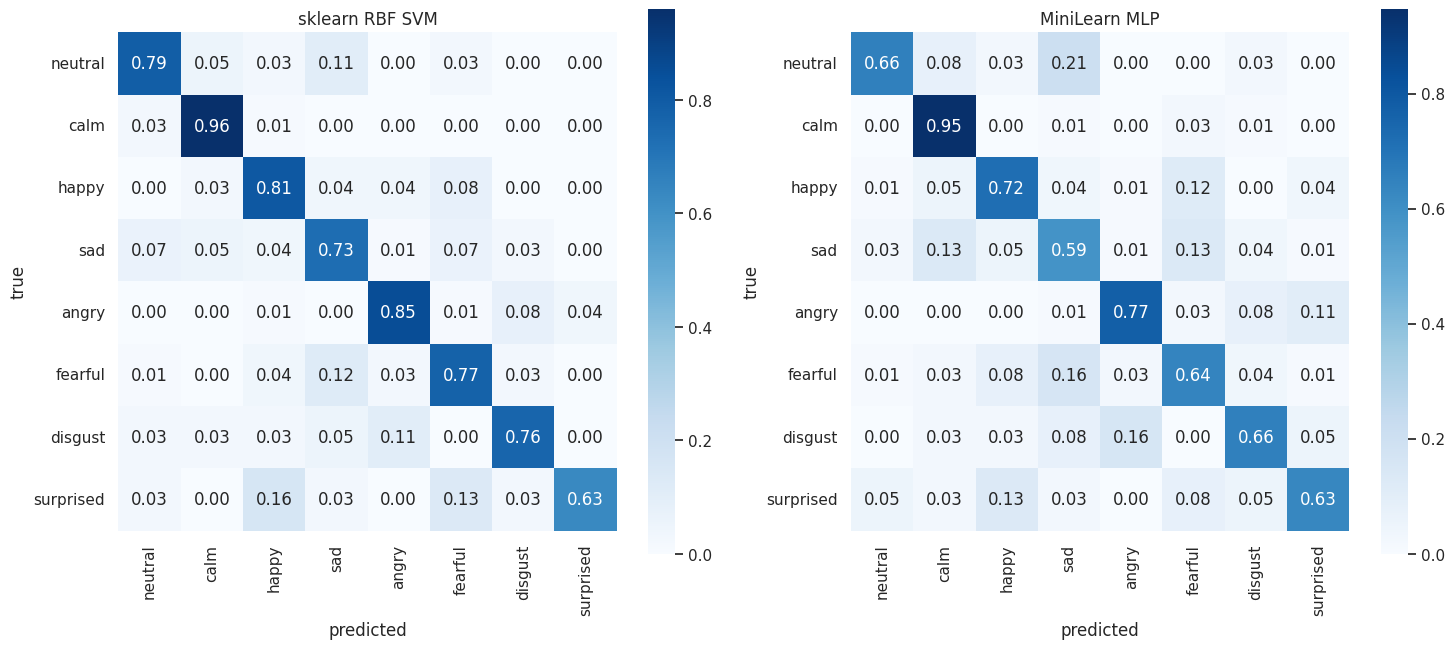

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, name in zip(axes, [best_overall, best_minilearn]):
    cm = confusion_matrix(y_test, predictions[name], labels=labels)
    plot_confusion_matrix(cm, target_names, ax=ax, normalize=True, title=name)
plt.tight_layout()
plt.show()

In [15]:
best_report = classification_report(
    y_test,
    predictions[best_overall],
    labels=labels,
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)
per_class_f1 = pd.DataFrame([
    {"emotion": emotion, "f1": best_report[emotion]["f1-score"], "support": best_report[emotion]["support"]}
    for emotion in target_names
]).sort_values("f1")
per_class_f1

,emotion,f1,support
3,sad,0.738255,75.0
7,surprised,0.738462,38.0
6,disgust,0.743590,38.0
5,fearful,0.768212,75.0
0,neutral,0.769231,38.0
2,happy,0.802632,75.0
4,angry,0.859060,75.0
1,calm,0.923077,75.0


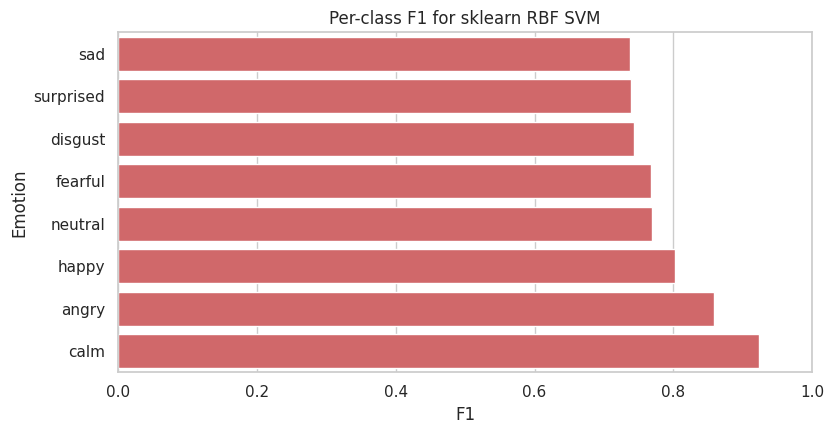

In [16]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
sns.barplot(data=per_class_f1, x="f1", y="emotion", color="#E15759", ax=ax)
ax.set_xlim(0, 1)
ax.set_title(f"Per-class F1 for {best_overall}")
ax.set_xlabel("F1")
ax.set_ylabel("Emotion")
plt.tight_layout()
plt.show()

The hardest classes are the ones that are acoustically close in this summary-feature representation. Sad/fearful/neutral/surprised mistakes are plausible because the model sees clip-level aggregate features, not the full temporal contour of the performance.

## 8. ROC/AUC for top scored models

For multiclass SER, ROC/AUC is computed one-vs-rest. It complements F1 by asking whether each model ranks the true class above competing classes across thresholds.

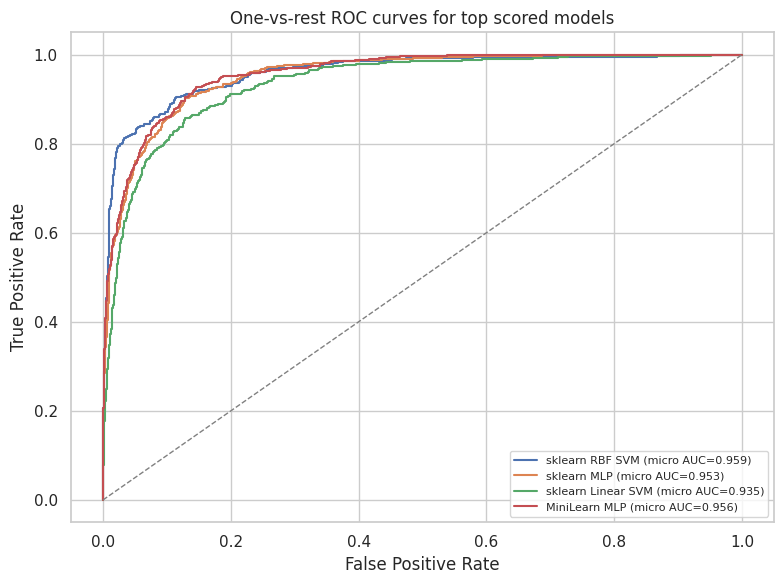

,model,macro_auc_ovr,micro_auc_ovr
0,sklearn RBF SVM,0.9576,0.9595
1,sklearn MLP,0.9482,0.9528
2,sklearn Linear SVM,0.9289,0.9350
3,MiniLearn MLP,0.9522,0.9562


In [17]:
def score_matrix(name):
    spec = fitted[name]
    model = spec["model"]
    Xte = X_test_s if spec["scaled"] else X_test
    if spec["kind"] == "xgboost":
        scores = model.predict_proba(Xte)
    elif hasattr(model, "predict_proba"):
        scores = model.predict_proba(Xte)
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(Xte)
    else:
        return None
    scores = np.asarray(scores, dtype=float)
    if scores.ndim != 2 or scores.shape[1] != len(labels):
        return None
    return scores

candidate_names = []
for name in results["model"]:
    if score_matrix(name) is not None:
        candidate_names.append(name)
    if len(candidate_names) == 4:
        break

y_test_bin = label_binarize(y_test, classes=labels)
roc_rows = []
fig, ax = plt.subplots(figsize=(8, 6))
for name in candidate_names:
    scores = score_matrix(name)
    macro_auc = roc_auc_score(y_test_bin, scores, average="macro", multi_class="ovr")
    micro_fpr, micro_tpr, _ = roc_curve(y_test_bin.ravel(), scores.ravel())
    micro_auc = auc(micro_fpr, micro_tpr)
    roc_rows.append({"model": name, "macro_auc_ovr": macro_auc, "micro_auc_ovr": micro_auc})
    ax.plot(micro_fpr, micro_tpr, label=f"{name} (micro AUC={micro_auc:.3f})")

ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("One-vs-rest ROC curves for top scored models")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

pd.DataFrame(roc_rows).round(4)

## 9. Neural-network result

The project requirement asks for at least one neural network. Notebook 11 added a from-scratch MiniLearn dense MLP with one hidden ReLU layer, softmax output, cross-entropy loss, mini-batch gradient descent, L2 regularization, and validation-loss tracking. The final comparison keeps that model small on purpose: it is an ANN concept demonstration, not a deep audio model.

In [18]:
nn_rows = results_display[results_display["family"].str.contains("neural net")].copy()
svm_row = results_display[results_display["model"].eq("sklearn RBF SVM")].copy()
pd.concat([nn_rows, svm_row], ignore_index=True)[["model", "family", "accuracy", "macro_f1", "weighted_f1", "best_hyperparameters"]]

,model,family,accuracy,macro_f1,weighted_f1,best_hyperparameters
0,sklearn MLP,sklearn neural net,0.7137,0.7044,0.7119,"64 hidden, Adam, early stopping, alpha=0.003"
1,MiniLearn MLP,MiniLearn neural net,0.7137,0.7026,0.7122,"64 hidden, ReLU, softmax, L2=0.003"
2,sklearn RBF SVM,sklearn kernel,0.8037,0.7928,0.8024,"C=10, gamma=scale"


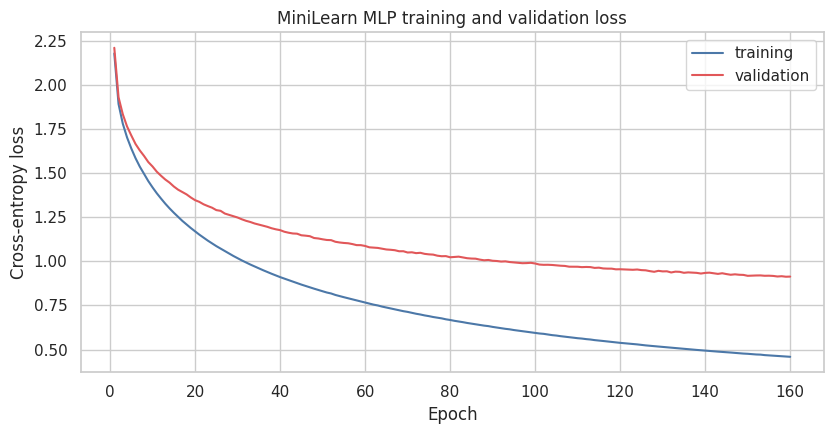

,epoch,training_loss,validation_loss
155,156,0.4655,0.9169
156,157,0.4639,0.9137
157,158,0.4622,0.9153
158,159,0.4605,0.9124
159,160,0.4589,0.9132


In [19]:
mini_mlp_model = fitted["MiniLearn MLP"]["model"]
loss_df = pd.DataFrame({
    "epoch": np.arange(1, len(mini_mlp_model.loss_history_) + 1),
    "training_loss": mini_mlp_model.loss_history_,
    "validation_loss": mini_mlp_model.val_loss_history_,
})
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(loss_df["epoch"], loss_df["training_loss"], label="training", color="#4C78A8")
ax.plot(loss_df["epoch"], loss_df["validation_loss"], label="validation", color="#E15759")
ax.set_title("MiniLearn MLP training and validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.legend()
plt.tight_layout()
plt.show()
loss_df.tail().round(4)

The neural networks learn useful signal, but they do not beat the RBF SVM. That is a reasonable outcome for a small tabular dataset made from summary statistics. Neural networks would be more compelling with raw spectrograms, frame sequences, or a much larger dataset.

## 10. Clustering and unsupervised analysis

K-Means asks a different question from classification: do emotion groups emerge without labels? The labels are used only after clustering to compute ARI/NMI and inspect composition.

In [20]:
cluster_scaler = StandardScaler()
X_scaled_full = cluster_scaler.fit_transform(X)

mini_kmeans = KMeans(n_clusters=8, max_iter=100, n_init=6, random_state=RANDOM_STATE)
mini_clusters = mini_kmeans.fit_predict(X_scaled_full)

sk_kmeans = SkKMeans(n_clusters=8, n_init=10, random_state=RANDOM_STATE)
sk_clusters = sk_kmeans.fit_predict(X_scaled_full)

cluster_scores = pd.DataFrame([
    {
        "model": "MiniLearn KMeans",
        "k": 8,
        "inertia": mini_kmeans.inertia_,
        "ARI": adjusted_rand_score(y, mini_clusters),
        "NMI": normalized_mutual_info_score(y, mini_clusters),
        "silhouette": silhouette_score(X_scaled_full, mini_clusters),
    },
    {
        "model": "sklearn KMeans",
        "k": 8,
        "inertia": sk_kmeans.inertia_,
        "ARI": adjusted_rand_score(y, sk_clusters),
        "NMI": normalized_mutual_info_score(y, sk_clusters),
        "silhouette": silhouette_score(X_scaled_full, sk_clusters),
    },
])
cluster_scores.round(4)

,model,k,inertia,ARI,NMI,silhouette
0,MiniLearn KMeans,8,573478.6374,0.0806,0.1632,0.097
1,sklearn KMeans,8,571641.7679,0.0839,0.1716,0.098


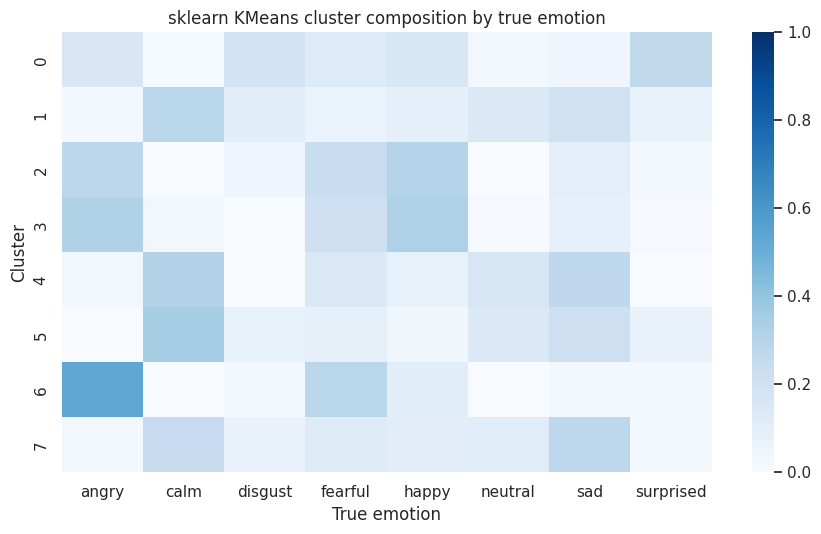

emotion,angry,calm,disgust,fearful,happy,neutral,sad,surprised
cluster,,,,,,,,
0,0.16,0.02,0.19,0.13,0.16,0.03,0.05,0.27
1,0.02,0.29,0.11,0.07,0.09,0.14,0.20,0.08
2,0.28,0.00,0.05,0.24,0.30,0.00,0.10,0.02
3,0.32,0.03,0.00,0.22,0.32,0.01,0.08,0.01
4,0.03,0.31,0.00,0.15,0.08,0.16,0.27,0.00
5,0.00,0.35,0.08,0.09,0.04,0.14,0.22,0.07
6,0.54,0.00,0.02,0.29,0.11,0.00,0.02,0.02
7,0.03,0.25,0.07,0.12,0.11,0.11,0.28,0.02


In [21]:
def composition_table(cluster_labels):
    tmp = pd.DataFrame({"cluster": cluster_labels, "emotion": [emotion_names[i] for i in y]})
    counts = pd.crosstab(tmp["cluster"], tmp["emotion"])
    return counts.div(counts.sum(axis=1), axis=0)

sk_comp = composition_table(sk_clusters)
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(sk_comp, cmap="Blues", vmin=0, vmax=1, ax=ax)
ax.set_title("sklearn KMeans cluster composition by true emotion")
ax.set_xlabel("True emotion")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.show()
sk_comp.round(2)

The clustering scores are modest, which is not a code failure. K-Means forms compact distance-based groups, but emotional speech categories are not clean spherical clusters in this feature space. With labels available, supervised learning is the right tool for this SER task.

## 11. Dimensionality reduction summary

PCA helps explain the structure of the feature table. It shows how much variance can be compressed and gives a 2D view for visual inspection, but it is not a replacement for supervised validation.

In [22]:
full_pca = PCA(n_components=min(X_scaled_full.shape))
X_pca_full = full_pca.fit_transform(X_scaled_full)
cum_var = np.cumsum(full_pca.explained_variance_ratio_)
checkpoints = [2, 5, 10, 20, 30, 50, 75, 100, 150, 200, 300, len(feature_cols)]
checkpoints = [c for c in checkpoints if c <= len(cum_var)]
variance_table = pd.DataFrame({
    "components": checkpoints,
    "cumulative_variance": [cum_var[c - 1] for c in checkpoints],
})
variance_table.round(4)

,components,cumulative_variance
0,2,0.4564
1,5,0.6201
2,10,0.7130
3,20,0.8048
4,30,0.8558
5,50,0.9112
6,75,0.9473
7,100,0.9678
8,150,0.9888
9,200,0.9966


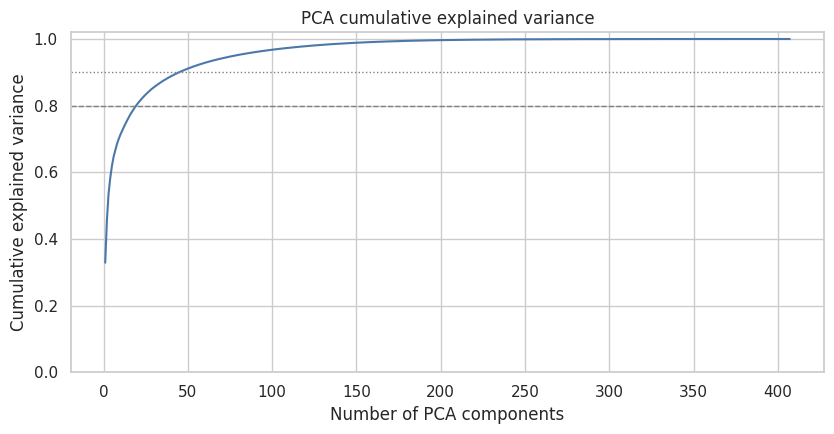

In [23]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(np.arange(1, len(cum_var) + 1), cum_var, color="#4C78A8")
ax.axhline(0.80, color="gray", linestyle="--", linewidth=1)
ax.axhline(0.90, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA cumulative explained variance")
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

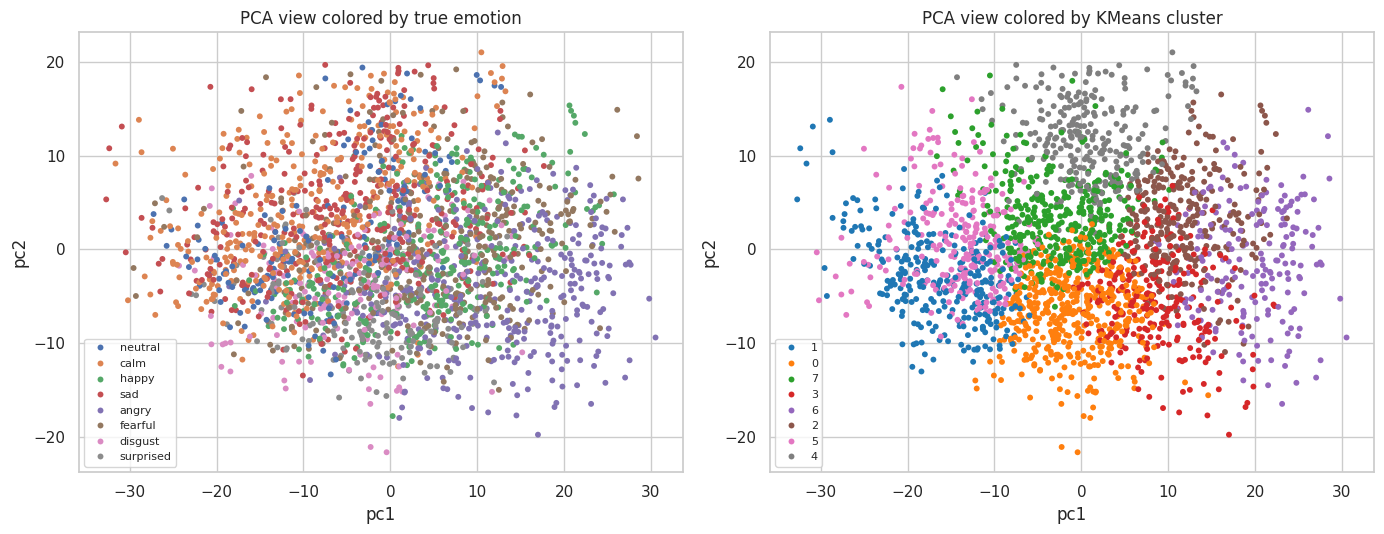

PCA-2 explained variance: [0.3288, 0.1276]


In [24]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled_full)
pca_df = pd.DataFrame({
    "pc1": X_pca2[:, 0],
    "pc2": X_pca2[:, 1],
    "emotion": [emotion_names[i] for i in y],
    "cluster": sk_clusters.astype(str),
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.scatterplot(data=pca_df, x="pc1", y="pc2", hue="emotion", s=18, linewidth=0, ax=axes[0])
axes[0].set_title("PCA view colored by true emotion")
axes[0].legend(loc="best", fontsize=8)
sns.scatterplot(data=pca_df, x="pc1", y="pc2", hue="cluster", palette="tab10", s=18, linewidth=0, ax=axes[1])
axes[1].set_title("PCA view colored by KMeans cluster")
axes[1].legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

print("PCA-2 explained variance:", np.round(pca2.explained_variance_ratio_, 4).tolist())

The PCA view confirms the story from clustering and classification: there is structure, but not clean class separation in two dimensions. The best supervised model succeeds because it uses the full scaled feature space and nonlinear boundaries.

## 12. Final discussion

- **Best model.** The validated RBF SVM is the best final model by held-out macro F1 and accuracy. It is strong because it can model nonlinear relationships among the summary audio features.
- **Simple vs advanced models.** Advanced models did not all win. RBF SVM beat tree ensembles and shallow neural networks, while simple logistic regression remained a strong MiniLearn baseline.
- **Hardest emotions.** The lower per-class F1 scores come from emotionally and acoustically similar categories, especially sad, fearful, neutral, and surprised.
- **MiniLearn vs sklearn.** MiniLearn matches the expected behavior of the library versions for the simpler models. The gap for more complex models is expected because sklearn has optimized solvers and mature implementations.
- **Feature limitation.** The project uses clip-level summary features. That makes the pipeline practical for classical ML, but it discards temporal dynamics that CNN/RNN/audio-transformer models could use.
- **Unsupervised result.** K-Means does not recover the emotion labels cleanly, so clustering is best interpreted as exploratory analysis rather than the final SER method.

## 13. Conclusion

The project successfully builds an end-to-end SER workflow: RAVDESS audio audit, feature extraction, MiniLearn from-scratch models, sklearn/XGBoost comparisons, validation, clustering, PCA/t-SNE analysis, and a shallow neural network. The practical takeaway is that a tuned RBF SVM is the strongest model for this fixed tabular feature representation, while the MiniLearn implementations make the modeling assumptions and training mechanics explainable.

## References

1. Livingstone SR, Russo FA (2018). *The Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS).* PLoS ONE 13(5): e0196391. https://doi.org/10.1371/journal.pone.0196391
2. RAVDESS dataset on Zenodo: https://zenodo.org/records/1188976
3. McFee B, et al. *librosa: Audio and music analysis in Python.* https://librosa.org
4. Pedregosa F, et al. *Scikit-learn: Machine Learning in Python.* JMLR 12, 2011.
5. Chen T, Guestrin C. *XGBoost: A Scalable Tree Boosting System.* KDD 2016.